In [1]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv(r"C:\Users\shiva\Videos\Vidder\Project data\Blinkit\blinkit_data.csv",encoding='latin1')
df.head(2)

,ï»¿Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.1,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.8,115.3492,5.0


In [6]:
df=df.rename(columns={'ï»¿Item Fat Content':"Item Fat Content"})

In [11]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

In [10]:
df['Item Fat Content']=df['Item Fat Content'].replace({'low fat':'Low Fat','LF':'Low Fat','reg':'Regular'})

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [14]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [15]:
df.shape

(8523, 12)

# Bussiness Requirement KPI's 

In [24]:
# Total sale by Outlet Establishment
Total_Sale = df['Sales'].sum()
print("Total Revenue:",round(Total_Sale,2))
# Averge Sales 
print("Averge Sales:",round(df['Sales'].mean(),2))
# Averge Rating 
print("Averge Rating:",round(df['Rating'].mean(),2))
# Number of items 
print("Number of Items:",round(df['Sales'].count(),2))

Total Revenue: 1201681.48
Averge Sales: 140.99
Averge Rating: 3.97
Number of Items: 8523


# Bussiness requirment charts

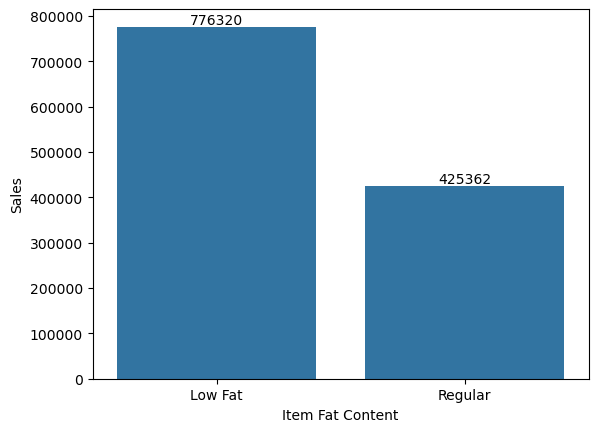

In [31]:
Total_Sale_Fat =df.groupby('Item Fat Content')['Sales'].sum().reset_index()
ax=sns.barplot(x='Item Fat Content',y='Sales',data=Total_Sale_Fat)
for bar in ax.containers:
    ax.bar_label(bar)
plt.show()

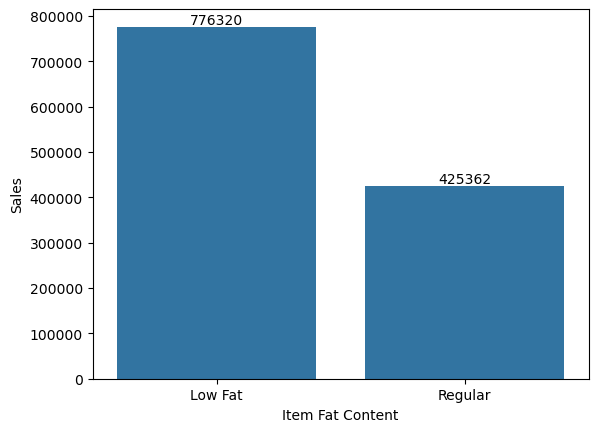

In [31]:
Total_Sale_Fat =df.groupby('Item Fat Content')['Sales'].sum().reset_index()
ax=sns.barplot(x='Item Fat Content',y='Sales',data=Total_Sale_Fat)
for bar in ax.containers:
    ax.bar_label(bar)
plt.show()

# Total Sales by Fat conant in pie chart show everything 

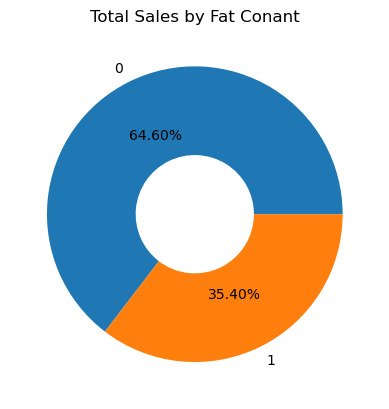

In [39]:
total_fat=df.groupby('Item Fat Content')['Sales'].sum().reset_index()
plt.pie(total_fat['Sales'],labels=total_fat['Item Fat Content'].index,autopct="%1.2f%%", wedgeprops={'width':0.6})
plt.title("Total Sales by Fat Conant")
plt.show()

# Total Sales by item type 

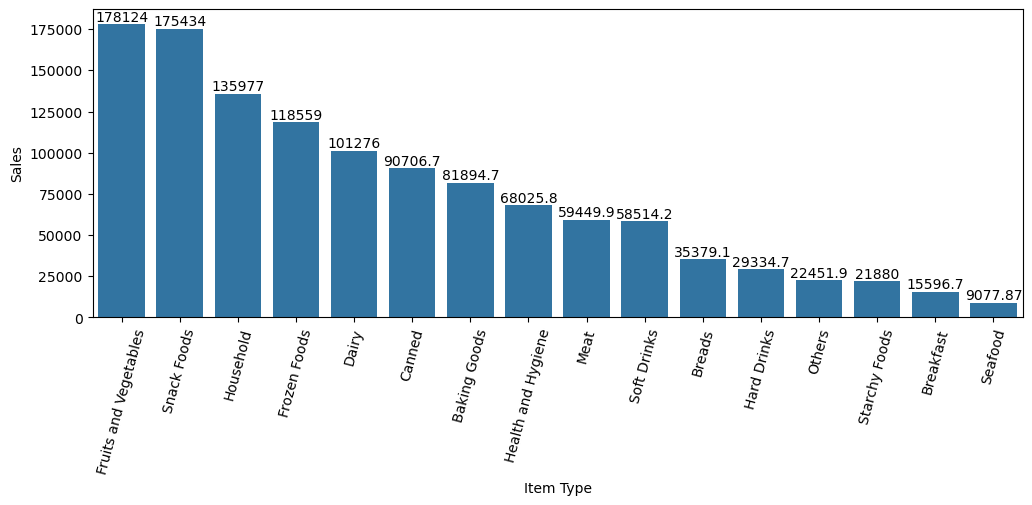

In [50]:
plt.figure(figsize=(12,4))
Total_itemtype=df.groupby('Item Type')['Sales'].sum().reset_index()
Total_itemtype = Total_itemtype.sort_values(by='Sales', ascending=False)

ax=sns.barplot(x='Item Type',y='Sales',data=Total_itemtype)
for bar in ax.containers:
    ax.bar_label(bar)
plt.xticks(rotation=75)
plt.show()

# Fat Conant by outlet for total_sales

Item Fat Content          Regular      Low Fat
Outlet Location Type                          
Tier 1                121349.8994  215047.9126
Tier 2                138685.8682  254464.7734
Tier 3                165326.0348  306806.9924


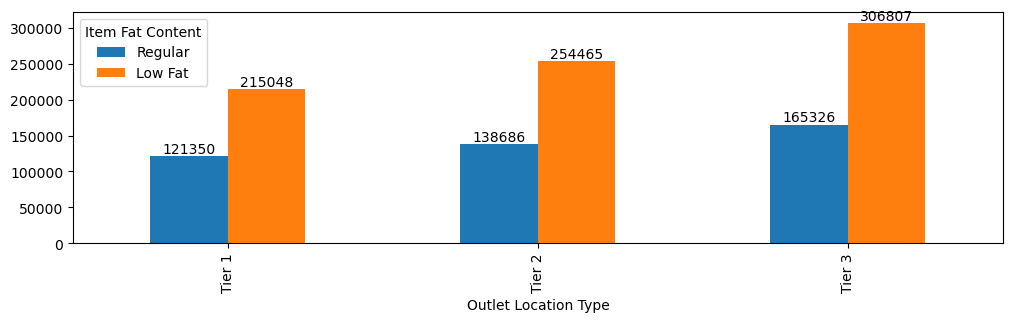

In [63]:
Sale_fat =df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
Sale_fat=Sale_fat[['Regular','Low Fat']]
print(Sale_fat)
ax=Sale_fat.plot(kind='bar',stacked=False,figsize=(12,3))
for bar in ax.containers:
    ax.bar_label(bar)
plt.show()



# Bussines Requirement Charts 

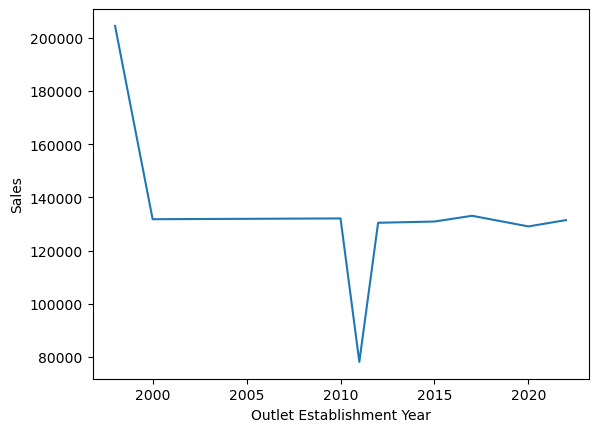

In [65]:
# Total Sales by Outlet Estabilish 
outlet_sales=df.groupby('Outlet Establishment Year')['Sales'].sum().reset_index()
sns.lineplot(x='Outlet Establishment Year',y='Sales',data=outlet_sales)
plt.show()


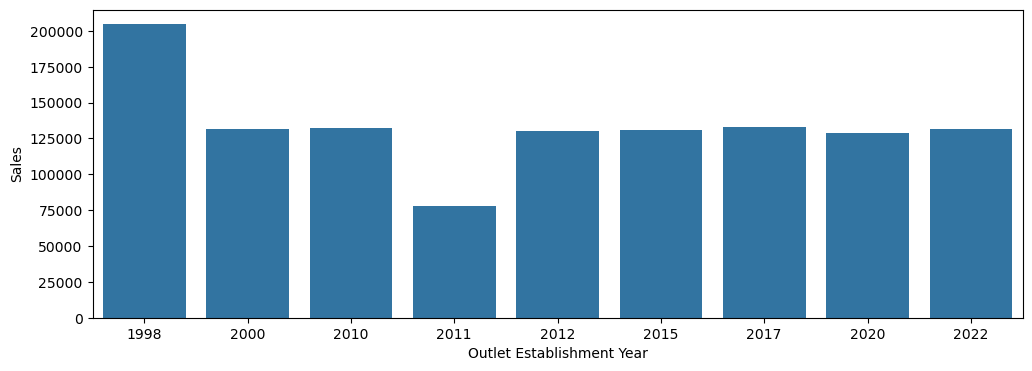

In [72]:
# Total Sales by Outlet Estabilish
plt.figure(figsize=(12,4))
ax=outlet_sales=df.groupby('Outlet Establishment Year')['Sales'].sum().reset_index()

sns.barplot(x='Outlet Establishment Year',y='Sales',data=outlet_sales)
plt.show()

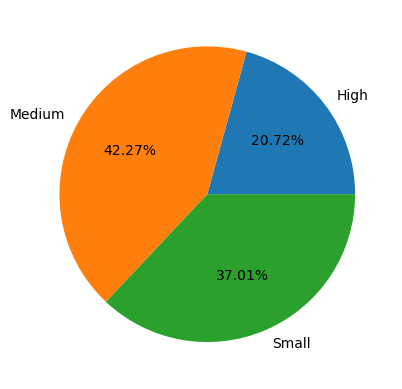

In [74]:
#  Sales by outletsize
total_size=df.groupby('Outlet Size')['Sales'].sum().reset_index()
plt.pie(total_size['Sales'],labels=total_size['Outlet Size'],autopct="%1.2f%%")
plt.show()


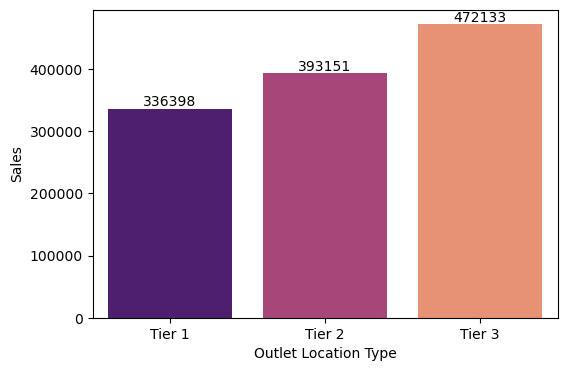

In [84]:
# Total sale by outlet_location 
plt.figure(figsize=(6,4))
location_sales=df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
ax=sns.barplot(x='Outlet Location Type',y='Sales',data=location_sales,palette='magma',hue='Outlet Location Type')
for bar in ax.containers:
    ax.bar_label(bar)
plt.show()

In [64]:
df.head(2)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.1,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.8,115.3492,5.0
